### Data Cleaning, Preprocessing and Feature Engineering on Bank Marketing Dataset

### Introduction

Data preprocessing is one of the most important steps in data analytics and machine learning. Real-world banking datasets often contain missing values, inconsistencies, duplicate records, and outliers that can affect analytical accuracy and model performance. This project demonstrates the process of data cleaning, preprocessing, and feature engineering using the Bank Marketing Dataset. Various preprocessing techniques such as handling missing values, removing duplicates, treating outliers, encoding categorical variables, and feature scaling were applied to prepare the dataset for analysis.

### Problem Statement

The objective of this project is to preprocess and clean the Bank Marketing Dataset by handling missing values, inconsistencies, duplicate records, and outliers. The project also focuses on feature engineering and data analysis to make the dataset suitable for machine learning and analytical applications.


### Dataset Description

The Bank Marketing Dataset contains customer-related banking information such as age, job type, marital status, education, account balance, housing loan details, personal loan information, and deposit subscription status. The dataset contains both numerical and categorical variables and is widely used for banking analytics and predictive analysis.

Bank Marketing Dataset
https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset

### Data Acquisition Method

The dataset was obtained from Kaggle in CSV format and imported into Python using the Pandas library. A subset of 4000 records was selected from the original dataset for efficient preprocessing and analysis.

### Methodology

The methodology followed in this project includes data acquisition, data cleaning, preprocessing, feature engineering, visualization, and analysis of the Bank Marketing Dataset. Various preprocessing techniques were applied to improve the quality of the dataset and prepare it for further analysis.

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

### Interpretation

Libraries such as Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn were imported to perform data manipulation, visualization, preprocessing, and feature engineering tasks.

In [2]:
#Loading the dataset 
df=pd.read_csv(r"C:\Users\admin\Downloads\bank (1).csv")

### Interpretation

The dataset was loaded successfully into the Python environment using the Pandas library for further preprocessing and analysis.

In [3]:
#Sampling Dataset 
df = df.sample(n=4000, random_state=42)

### Interpretation

A subset of 4000 rows was selected from the original dataset to maintain computational efficiency while preserving dataset complexity for preprocessing tasks.

In [4]:
#Displaying the dataset 
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
5527,65,retired,divorced,secondary,no,744,no,no,cellular,5,jul,182,1,-1,0,unknown,no
4541,38,blue-collar,married,secondary,no,1627,no,no,unknown,16,jun,1323,9,-1,0,unknown,yes
1964,35,blue-collar,single,secondary,no,4963,yes,no,cellular,14,may,456,1,300,1,failure,yes
5007,47,blue-collar,married,secondary,no,8229,no,no,cellular,8,aug,784,2,-1,0,unknown,yes
8928,35,technician,married,tertiary,no,1473,yes,no,unknown,12,may,84,3,-1,0,unknown,no


### Interpretation

The first few rows of the dataset were displayed to understand the structure, column names, and data values present in the dataset.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 5527 to 2214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4000 non-null   int64 
 1   job        4000 non-null   object
 2   marital    4000 non-null   object
 3   education  4000 non-null   object
 4   default    4000 non-null   object
 5   balance    4000 non-null   int64 
 6   housing    4000 non-null   object
 7   loan       4000 non-null   object
 8   contact    4000 non-null   object
 9   day        4000 non-null   int64 
 10  month      4000 non-null   object
 11  duration   4000 non-null   int64 
 12  campaign   4000 non-null   int64 
 13  pdays      4000 non-null   int64 
 14  previous   4000 non-null   int64 
 15  poutcome   4000 non-null   object
 16  deposit    4000 non-null   object
dtypes: int64(7), object(10)
memory usage: 562.5+ KB


In [6]:
#Final Dataset Shape
df.shape

(4000, 17)

### Interpretation

The dataset information provided details regarding the number of rows, columns, data types, and memory usage. Both numerical and categorical columns are present in the dataset.

In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,41.241000,1478.860500,15.743000,377.847000,2.530750,53.965000,0.878500
std,12.092497,3126.748617,8.475076,351.241629,2.737778,110.134555,2.506154
min,18.000000,-6847.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,32.000000,121.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,38.000000,544.000000,15.000000,259.000000,2.000000,-1.000000,0.000000
75%,49.000000,1625.000000,22.000000,504.000000,3.000000,85.000000,1.000000
max,95.000000,81204.000000,31.000000,3284.000000,43.000000,842.000000,58.000000


### Interpretation

The statistical summary provides information such as mean, standard deviation, minimum, and maximum values of numerical columns, helping identify variations and potential outliers.

In [8]:
#Checking missing values 
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

### Interpretation

Missing values were identified in the dataset, indicating the need for preprocessing techniques to improve data quality.

In [9]:
#Handling missing and inconsistent values
df.replace("unknown", np.nan, inplace=True)

In [10]:
df.isnull().sum()

age             0
job            22
marital         0
education     180
default         0
balance         0
housing         0
loan            0
contact       852
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     2934
deposit         0
dtype: int64

In [11]:
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_22536\3448830320.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


### Interpretation

Inconsistent values such as “unknown” were replaced with missing values and handled appropriately using suitable imputation techniques.

In [12]:
#Checking Duplicates
df.duplicated().sum()

np.int64(0)

### Interpretation

Duplicate records were checked to identify repeated entries that could affect the accuracy of analysis.

In [13]:
#Removing Duplicate Records
df.drop_duplicates(inplace=True)

### Interpretation

Duplicate rows were removed from the dataset to maintain data consistency and improve analytical accuracy.

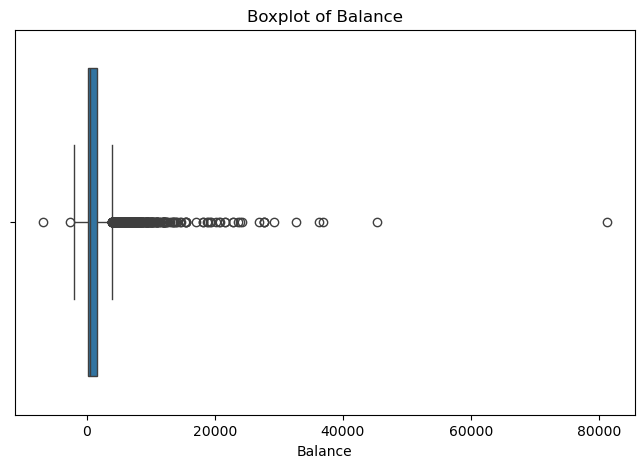

In [14]:
#Outlier Detection Using Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['balance'])
plt.title("Boxplot of Balance")
plt.xlabel("Balance")
plt.show()


In [15]:
#Removing Outliers Using IQR Method
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['balance'] >= lower) & (df['balance'] <= upper)]

### Interpretation

Outliers were removed using the Interquartile Range (IQR) method to reduce the influence of extreme values on analysis.

In [16]:
#Encoding Categorical Variables 
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

### Interpretation

Categorical variables were converted into numerical format using Label Encoding to make the dataset compatible with machine learning algorithms.

In [17]:
#Feature Engineering
df['balance_per_age'] = df['balance'] / df['age']

In [18]:
df['loan_balance_ratio'] = df['balance'] / (df['campaign'] + 1)

In [19]:
# Feature Selection

correlation = df.corr(numeric_only=True)

target_corr = correlation['deposit'].sort_values(ascending=False)

print(target_corr)

deposit               1.000000
duration              0.453379
poutcome              0.303510
loan_balance_ratio    0.156022
balance               0.137596
pdays                 0.132020
balance_per_age       0.128759
previous              0.128391
job                   0.081191
marital               0.080054
education             0.071603
age                   0.030279
contact               0.021497
default              -0.049314
month                -0.060105
day                  -0.063956
loan                 -0.106527
campaign             -0.127320
housing              -0.218767
Name: deposit, dtype: float64


### Interpretation:
Feature selection helps identify the most important variables influencing deposit subscription. Variables with higher correlation values have greater impact on prediction and analysis.

In [20]:
# Feature Selection - Variance threshold
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

selected_features = selector.fit_transform(df)

print(selected_features.shape)

(3615, 19)


### Interpretation:
Variance Threshold removes features with very low variance, helping improve dataset quality and reducing unnecessary information.

In [21]:
#Feature Extraction Using PCA 
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(df.select_dtypes(include=np.number))

print(pca_features[:5])

[[-2.32108186e+00 -1.89204342e+02]
 [ 7.64932313e+02  9.41862976e+02]
 [ 6.76368311e+02 -2.96336338e+02]
 [-6.94026246e+02  6.89147695e+01]
 [ 2.99296391e+03 -7.81509916e+01]]


### Interpretation:
Principal Component Analysis (PCA) reduces dataset dimensionality while preserving important information. This improves computational efficiency and simplifies analysis.

### Interpretation

New features were created from existing columns to improve analytical insights and enhance dataset usefulness.

In [22]:
#Feature Scaling using StandardScaler
scaler = StandardScaler()

numerical_cols = ['age', 'balance', 'duration', 'campaign']

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

### Interpretation

Feature scaling was applied to normalize numerical values and improve the efficiency of machine learning algorithms.

In [23]:
print(df.shape)

(3615, 19)


### Interpretation

The final cleaned dataset contains processed records after handling missing values, duplicate rows, inconsistencies, and outliers.

### Analysis

The following visualizations and statistical techniques were used to analyze the cleaned dataset and identify relationships, trends, and customer behavior patterns.

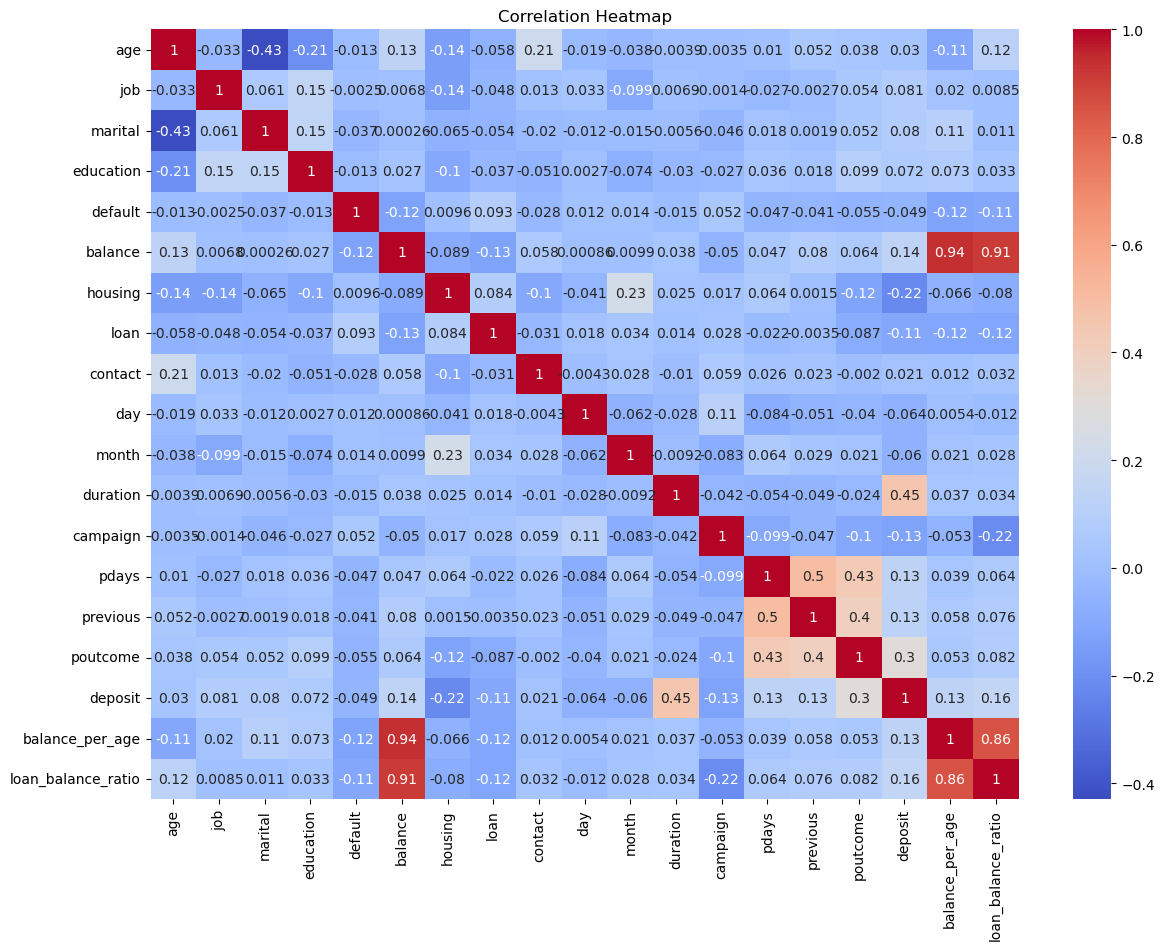

In [24]:
#Correlation Analysis Using Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Interpretation

The heatmap shows relationships between numerical variables. Some variables show moderate correlation with deposit subscription behavior.

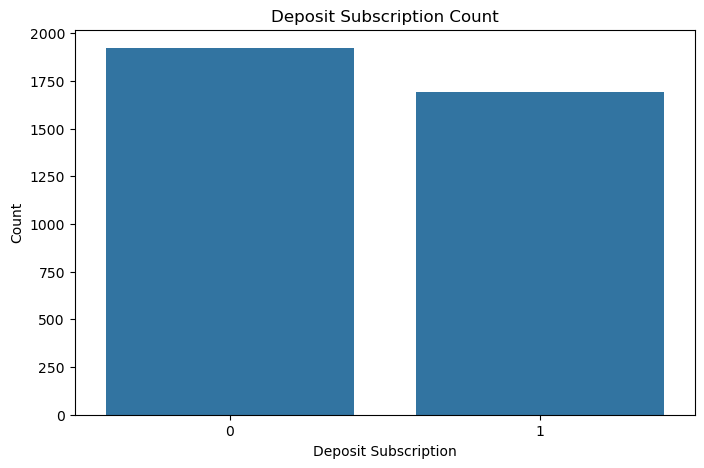

In [25]:
#Countplot Analysis of Deposit Subscription

plt.figure(figsize=(8,5))
sns.countplot(x='deposit', data=df)
plt.title("Deposit Subscription Count")
plt.xlabel("Deposit Subscription")
plt.ylabel("Count")
plt.show()

### Interpretation

The countplot indicates that the number of customers who did not subscribe to term deposits is higher compared to subscribers.

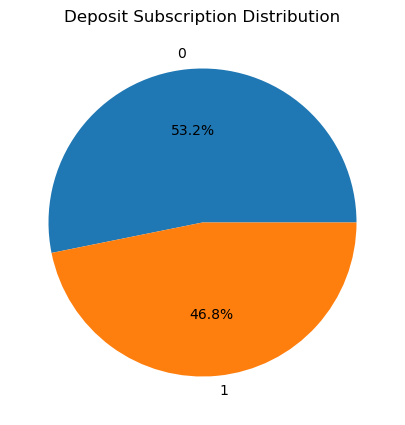

In [26]:
# Pie Chart Analysis of Deposit Subscription
plt.figure(figsize=(8,5))
df['deposit'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Deposit Subscription Distribution")
plt.ylabel("")
plt.show()

### Interpretation

The pie chart shows that the majority of customers did not subscribe to term deposits, indicating imbalance in customer responses.

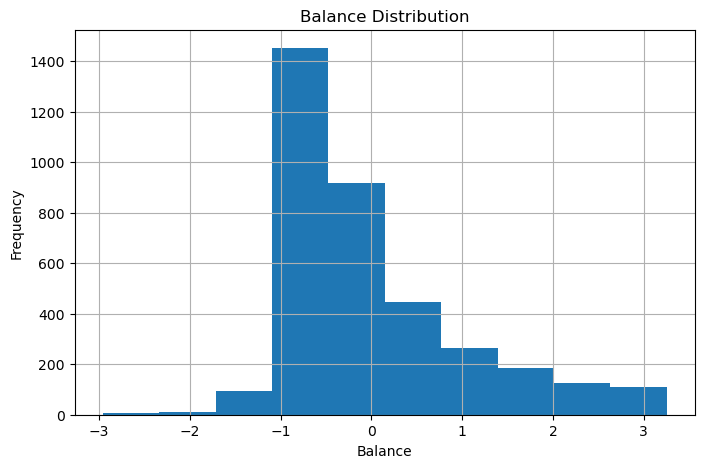

In [27]:
# Histogram Analysis of Account Balance
df['balance'].hist(figsize=(8,5))
plt.title("Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")

plt.show()

### Interpretation

The histogram shows that most customers maintain lower account balances, while only a few customers have high balances.

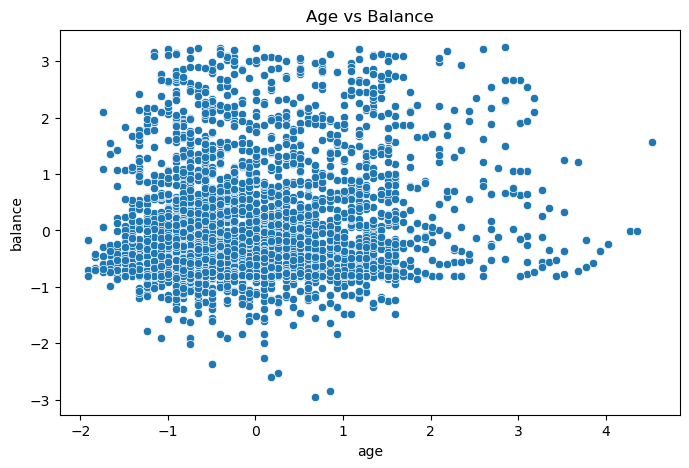

In [28]:
#Scatterplot Analysis of Age and Balance
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='balance', data=df)
plt.title("Age vs Balance")
plt.show()

### Interpretation

The scatterplot indicates that there is no strong linear relationship between age and account balance, although some older customers maintain higher balances.

In [29]:
#Final Cleaned Dataset
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,balance_per_age,loan_balance_ratio
5527,2.016448,5,0,1,0,-0.033427,0,0,0,5,5,-0.545885,-0.554707,-1,0,0,0,11.446154,372.00
4541,-0.241153,1,1,1,0,0.890911,0,0,0,16,6,2.730017,2.349897,-1,0,0,1,42.815789,162.70
8928,-0.491998,9,1,2,0,0.729702,1,0,0,12,8,-0.827251,0.171444,-1,0,0,0,42.085714,368.25
8936,-0.910072,4,2,2,0,-0.687688,0,0,0,28,4,0.166143,-0.554707,-1,0,0,0,3.966667,59.50
6141,0.511381,0,1,1,0,2.782509,1,1,1,9,5,-0.100867,-0.554707,-1,0,0,0,73.063830,1717.00


### Interpretation

The cleaned dataset is now structured, consistent, and suitable for further machine learning and analytical applications.

In [30]:
#Saving Cleaned Dataset 
df.to_csv("Cleaned_BankMarketing.csv", index=False)

### Interpretation

The final cleaned dataset was exported and saved successfully for future analysis and machine learning tasks.

### Conclusion

This project successfully demonstrated the complete preprocessing workflow on the Bank Marketing Dataset. 
Missing values, inconsistencies, duplicate records, and outliers were handled effectively using appropriate preprocessing techniques. 
Feature engineering and scaling improved the quality of the dataset and prepared it for analysis and predictive modeling. 
The project highlights the importance of preprocessing in improving data quality and analytical performance.

### References

Kaggle – Bank Marketing Dataset

Pandas Documentation

NumPy Documentation

Seaborn Documentation

Scikit-learn Documentation